In [1]:
# Execute esta célula apenas uma vez para garantir a leitura de arquivos .xls
%pip install -q xlrd

import pandas as pd
import matplotlib.pyplot as plt

# Configurações gerais do notebook
CAMINHO_ARQUIVO = r"C:/Users/User/Documents/Códigos Github/Projeto Cetesb/contaminantes_industria1.xls"
COLUNA_CONTAMINANTES = "Grupo de Contaminantes"
COR_INDUSTRIA = "lightslategrey"

# Estilo visual padrão para os gráficos
plt.style.use("seaborn-v0_8-whitegrid")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Lê a planilha e cria o DataFrame principal do segmento Indústria
industria = pd.read_excel(CAMINHO_ARQUIVO, header=1)

# Inspeciona a estrutura da base e mostra as primeiras linhas
industria.info()
industria.head()


<class 'pandas.DataFrame'>
RangeIndex: 1543 entries, 0 to 1542
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Detalhes                         0 non-null      float64
 1   Ficha                            0 non-null      float64
 2   NIS da Área                      1543 non-null   int64  
 3   Classificação Atual              1543 non-null   str    
 4   Nome                             1543 non-null   str    
 5   Endereço                         1543 non-null   str    
 6   Município                        1542 non-null   str    
 7   Coordenada                       1543 non-null   str    
 8   UGRHI                            1542 non-null   str    
 9   Grupo de Contaminantes           1437 non-null   str    
 10  Medidas de Intervenção Adotadas  1240 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 132.7 KB


,Detalhes,Ficha,NIS da Área,Classificação Atual,Nome,Endereço,Município,Coordenada,UGRHI,Grupo de Contaminantes,Medidas de Intervenção Adotadas
0,NaN,NaN,2,Área Reabilitada para o Uso Declarado (AR),CONDOMÍNIO LUMINA PARQUE CLUBE (MARSHALL EMPR....,"R. CONSELHEIRO COTEGIPE, 294",São Paulo,"-23,53807695 \ -46,59061814",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,METAIS; PAHs; Grupo TPH; CONTAMINANTES,Medidas de Controle Intitucional: Restrição ao...
1,NaN,NaN,3,Área Reabilitada para o Uso Declarado (AR),"PAULISTA S/A COM., PART. E EMPR.","EST. ELIAS ALVES DA COSTA, S/N",Itapevi,"-23,54568562 \ -46,96606185",10 - SOROCABA/MÉDIO TIETÊ; 06 - ALTO TIETÊ,METAIS,Medidas de Controle Intitucional: Restrição ao...
2,NaN,NaN,17,Área em Processo de Monitoramento para Encerra...,ROHM AND HAAS QUÍMICA LTDA.,"AVENIDA PRES. HUMBERTO DE ALENCAR CASTELO BRA,...",Jacareí,"-23,28309294 \ -45,98367024",02 - PARAÍBA DO SUL,METAIS; OUTROS INORGÂNICOS; SOLVENTES AROMÁTIC...,Medidas Emergenciais: Isolamento da Área (Prot...
3,NaN,NaN,20,Área em Processo de Monitoramento para Encerra...,KEMWATER BRASIL S/A,"EST. EIJI KIKUTI, 397 397",São Bernardo do Campo,"-23,72809792 \ -46,5910521",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,METAIS; SOLVENTES HALOGENADOS,Medidas Emergenciais: Fechamento/Interdição de...
4,NaN,NaN,24,Área em Processo de Monitoramento para Encerra...,PÉROLA S.A.,"RUA EDUARDO PEREIRA GUINLE, S/N",Santos,7350828 \ 366245,07 - BAIXADA SANTISTA,NaN,NaN


In [3]:
# Conta as combinações originais exatamente como aparecem na base,
# antes da separação dos contaminantes por ";"
freq_grupos_originais = (
    industria[COLUNA_CONTAMINANTES]
    .dropna()
    .value_counts()
    .rename_axis(COLUNA_CONTAMINANTES)
    .reset_index(name="Quantidade Observada")
)

print(f"Quantidade de combinações únicas: {freq_grupos_originais.shape[0]}")
freq_grupos_originais.head(10)


Quantidade de combinações únicas: 393


,Grupo de Contaminantes,Quantidade Observada
0,METAIS,285
1,METAIS; SOLVENTES HALOGENADOS,106
2,SOLVENTES HALOGENADOS,82
3,METAIS; Grupo TPH,37
4,SOLVENTES HALOGENADOS; SOLVENTES AROMÁTICOS,33
5,Grupo TPH,30
6,METAIS; SOLVENTES AROMÁTICOS,28
7,METAIS; OUTROS INORGÂNICOS,26
8,METAIS; SOLVENTES HALOGENADOS; SOLVENTES AROMÁ...,24
9,METAIS; PAHs,23


In [4]:
def extrair_contaminantes_individuais(serie_contaminantes: pd.Series) -> pd.Series:
    """
    Separa os contaminantes por ';', remove espaços extras
    e elimina valores vazios.
    """
    return (
        serie_contaminantes
        .dropna()
        .astype(str)
        .str.split(";")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]
    )


def criar_tabela_contaminantes(df: pd.DataFrame, coluna_contaminantes: str) -> pd.DataFrame:
    """
    Cria uma tabela-resumo com a frequência absoluta e percentual
    de cada contaminante.
    """
    contaminantes = extrair_contaminantes_individuais(df[coluna_contaminantes])

    tabela = (
        contaminantes
        .value_counts()
        .rename_axis("Grupo de Contaminantes")
        .reset_index(name="Quantidade Observada")
        .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
    )

    tabela["% do total"] = (
        tabela["Quantidade Observada"] / tabela["Quantidade Observada"].sum() * 100
    ).round(2)

    return tabela


# Gera a tabela final de contaminantes da atividade Indústria
df_contaminantes_industria = criar_tabela_contaminantes(
    industria,
    COLUNA_CONTAMINANTES
)

df_contaminantes_industria.info()
df_contaminantes_industria


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Grupo de Contaminantes  20 non-null     str    
 1   Quantidade Observada    20 non-null     int64  
 2   % do total              20 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 612.0 bytes


,Grupo de Contaminantes,Quantidade Observada,% do total
0,METAIS,1004,28.64
1,SOLVENTES HALOGENADOS,575,16.41
2,SOLVENTES AROMÁTICOS,445,12.70
3,Grupo TPH,379,10.81
4,PAHs,311,8.87
5,COMBUSTÍVEIS AUTOMOTIVOS,145,4.14
6,OUTROS INORGÂNICOS,133,3.79
7,CONTAMINANTES,129,3.68
8,PCBs,76,2.17
9,FENÓIS,71,2.03


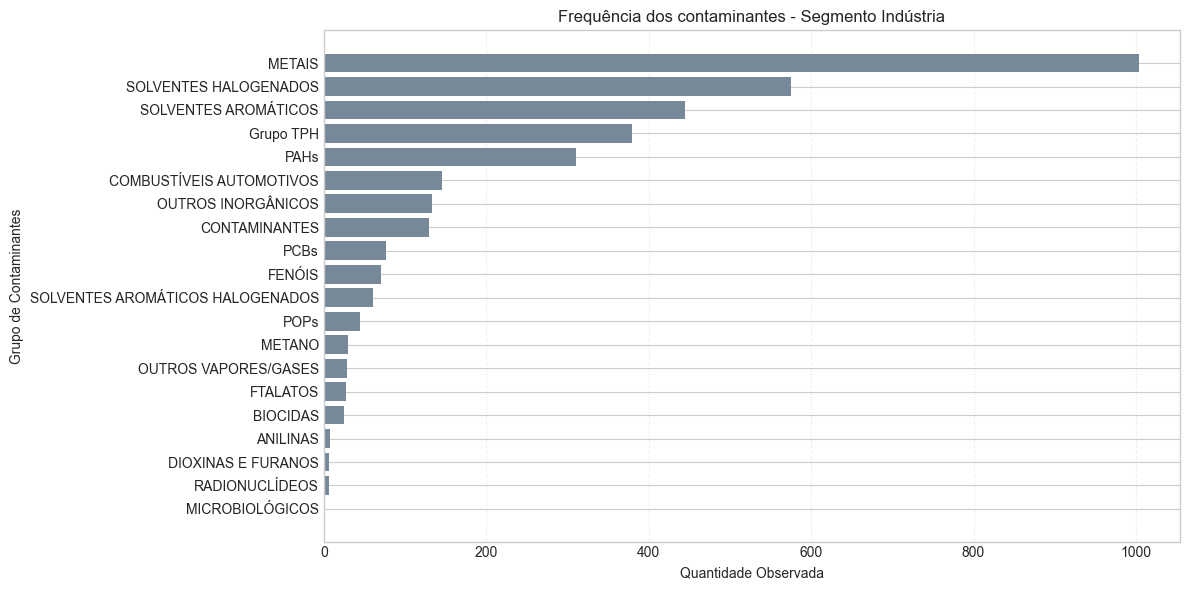

In [5]:
def plot_barh_frequencia(df_resumo: pd.DataFrame, titulo: str, cor: str) -> None:
    """
    Plota um gráfico de barras horizontal com a frequência absoluta
    dos contaminantes.
    """
    # Ordena em ordem crescente para o maior valor aparecer no topo
    df_plot = df_resumo.sort_values("Quantidade Observada", ascending=True)

    plt.figure(figsize=(12, 6))
    plt.barh(
        df_plot["Grupo de Contaminantes"],
        df_plot["Quantidade Observada"],
        color=cor
    )
    plt.title(titulo)
    plt.xlabel("Quantidade Observada")
    plt.ylabel("Grupo de Contaminantes")
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.gca().set_axisbelow(True)
    plt.tight_layout()
    plt.show()


plot_barh_frequencia(
    df_contaminantes_industria,
    "Frequência dos contaminantes - Segmento Indústria",
    COR_INDUSTRIA
)


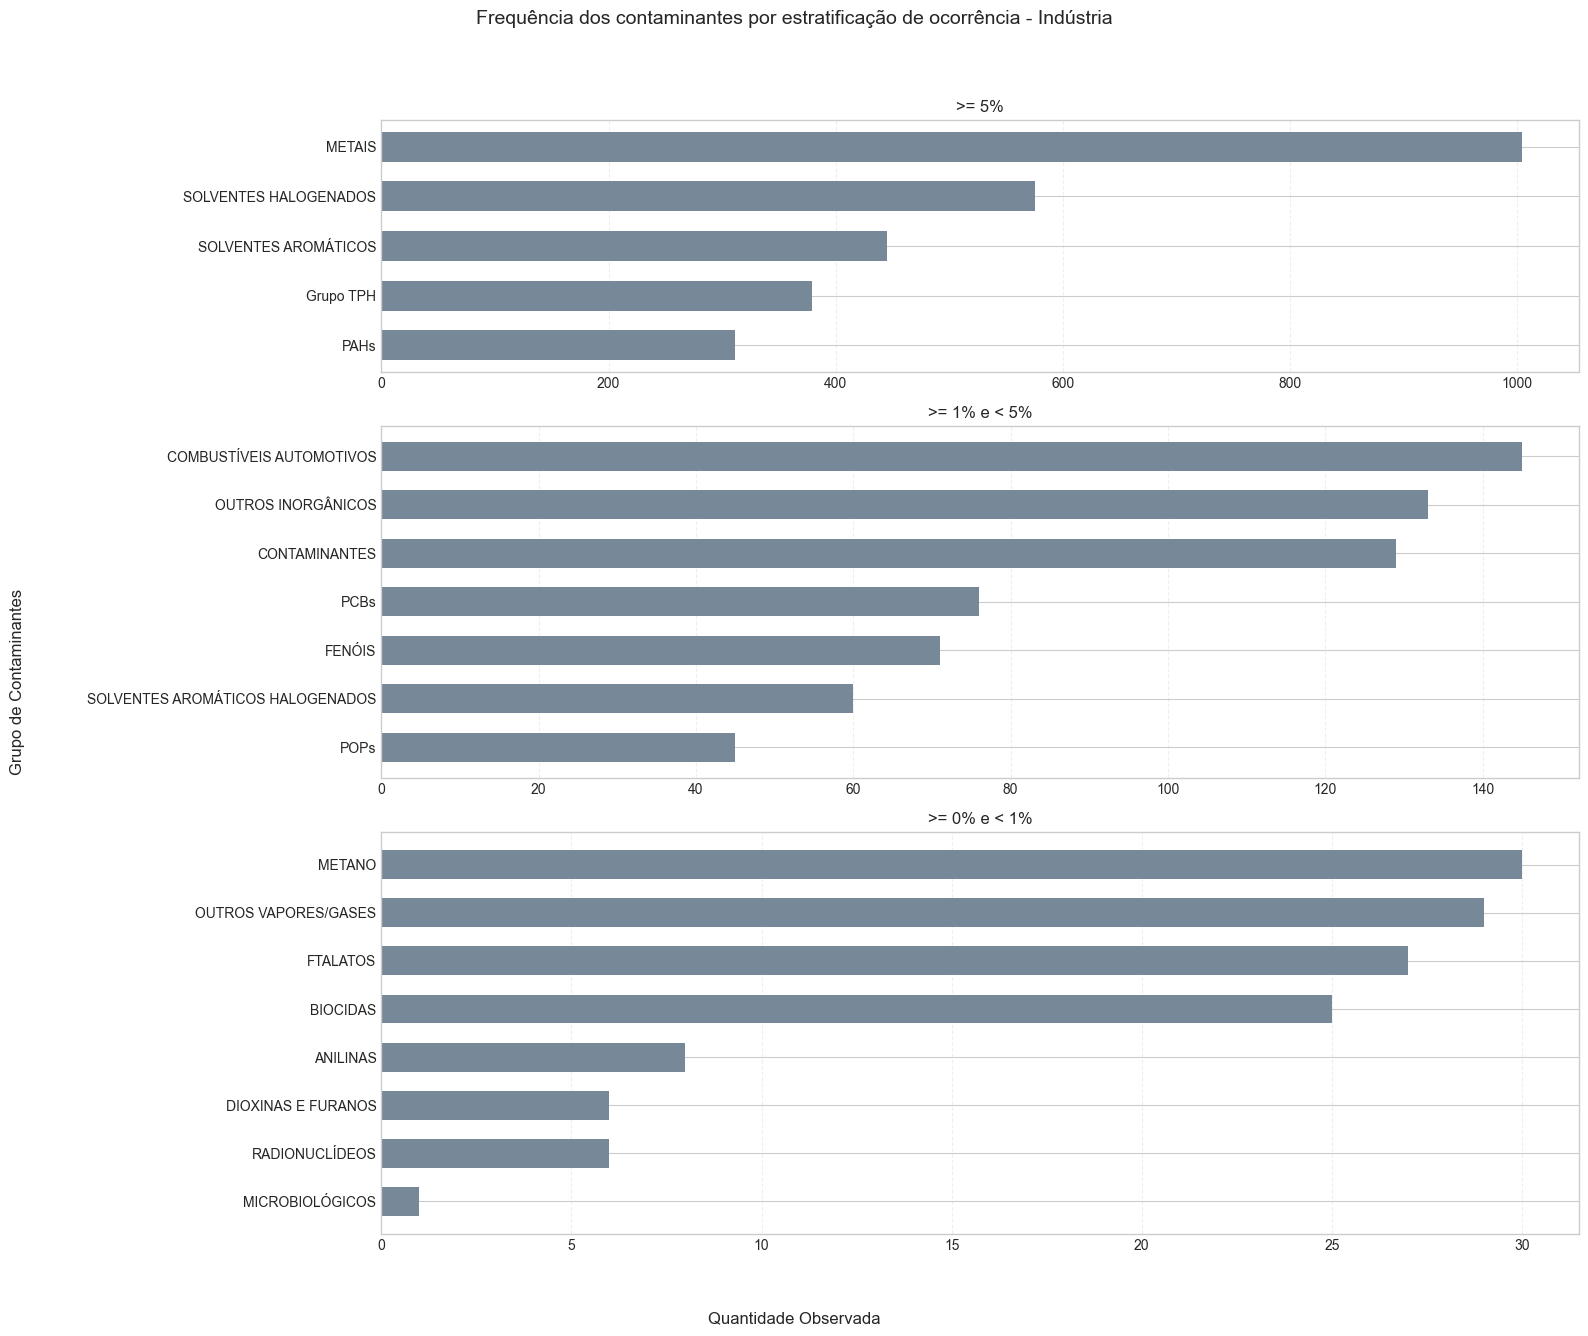

In [6]:
def criar_estratos_percentuais(df_resumo: pd.DataFrame) -> list[tuple[pd.DataFrame, str]]:
    """
    Organiza os contaminantes em faixas percentuais padronizadas.
    """
    estratos = [
        (df_resumo[df_resumo["% do total"] >= 5], ">= 5%"),
        (
            df_resumo[
                (df_resumo["% do total"] >= 1) &
                (df_resumo["% do total"] < 5)
            ],
            ">= 1% e < 5%"
        ),
        (
            df_resumo[
                (df_resumo["% do total"] >= 0) &
                (df_resumo["% do total"] < 1)
            ],
            ">= 0% e < 1%"
        ),
    ]

    # Ordena cada estrato para manter o mesmo padrão visual dos gráficos
    return [
        (df.sort_values("Quantidade Observada", ascending=True).copy(), subtitulo)
        for df, subtitulo in estratos
    ]


def plot_barh_estratificado(
    grupos: list[tuple[pd.DataFrame, str]],
    titulo_geral: str,
    cor: str
) -> None:
    """
    Plota uma figura composta com os contaminantes estratificados
    por participação percentual.
    """
    alturas = [max(1, len(df)) for df, _ in grupos]

    fig, axes = plt.subplots(
        nrows=len(grupos),
        ncols=1,
        figsize=(16, sum(alturas) * 0.7),
        gridspec_kw={"height_ratios": alturas}
    )

    # Garante compatibilidade caso exista apenas um único estrato
    if len(grupos) == 1:
        axes = [axes]

    for ax, (df, subtitulo) in zip(axes, grupos):
        if df.empty:
            ax.text(0.5, 0.5, f"Sem dados ({subtitulo})", ha="center", va="center")
            ax.set_axis_off()
            continue

        ax.barh(
            df["Grupo de Contaminantes"],
            df["Quantidade Observada"],
            color=cor,
            height=0.6
        )
        ax.set_title(subtitulo)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        ax.set_axisbelow(True)

    fig.suptitle(
        "Frequência dos contaminantes por estratificação de ocorrência - Indústria",
        fontsize=14,
        y=0.98
    )
    fig.supxlabel("Quantidade Observada", fontsize=12, y=0.04)
    fig.supylabel("Grupo de Contaminantes", fontsize=12, x=0.01)

    plt.tight_layout(rect=[0.03, 0.06, 1, 0.95])
    plt.show()


grupos_industria = criar_estratos_percentuais(df_contaminantes_industria)

plot_barh_estratificado(
    grupos_industria,
    "Frequência dos contaminantes por estratificação de ocorrência - Indústria",
    COR_INDUSTRIA
)


In [7]:
# Inspeciona a estrutura do DataFrame consolidado de contaminantes da Indústria
# Esta célula ajuda a validar tipos, valores nulos e tamanho da tabela-resumo.
df_contaminantes_industria.info()
df_contaminantes_industria.head()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Grupo de Contaminantes  20 non-null     str    
 1   Quantidade Observada    20 non-null     int64  
 2   % do total              20 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 612.0 bytes


,Grupo de Contaminantes,Quantidade Observada,% do total
0,METAIS,1004,28.64
1,SOLVENTES HALOGENADOS,575,16.41
2,SOLVENTES AROMÁTICOS,445,12.70
3,Grupo TPH,379,10.81
4,PAHs,311,8.87


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Define constantes para padronizar a leitura e a visualização.
CAMINHO_ARQUIVO_RESIDUOS = r"C:/Users/User/Documents/Códigos Github/Projeto Cetesb/contaminantes_disposição_residuos.xls"
COLUNA_CONTAMINANTES = "Grupo de Contaminantes"
COR_RESIDUOS = "lime"

# Lê a planilha da atividade Disposição de Resíduos.
disposicao_residuos = pd.read_excel(CAMINHO_ARQUIVO_RESIDUOS, header=1)

# Exibe a estrutura da base original e as primeiras linhas.
disposicao_residuos.info()
disposicao_residuos.head()


<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Detalhes                         0 non-null      float64
 1   Ficha                            0 non-null      float64
 2   NIS da Área                      230 non-null    int64  
 3   Classificação Atual              230 non-null    str    
 4   Nome                             230 non-null    str    
 5   Endereço                         230 non-null    str    
 6   Município                        230 non-null    str    
 7   Coordenada                       230 non-null    str    
 8   UGRHI                            230 non-null    str    
 9   Grupo de Contaminantes           222 non-null    str    
 10  Medidas de Intervenção Adotadas  192 non-null    str    
dtypes: float64(2), int64(1), str(8)
memory usage: 19.9 KB


,Detalhes,Ficha,NIS da Área,Classificação Atual,Nome,Endereço,Município,Coordenada,UGRHI,Grupo de Contaminantes,Medidas de Intervenção Adotadas
0,NaN,NaN,67,Área Contaminada com Risco Confirmado (ACRi),REDE FERROVIÁRIA FEDERAL S/A (RFFSA),"EST. QUE LIGA IPERÓ A TATUI,",Iperó,"-23,34935074 \ -47,72195146",10 - SOROCABA/MÉDIO TIETÊ,BIOCIDAS; PAHs; POPs; Grupo TPH,Medidas Emergenciais: Isolamento da Área (Prot...
1,NaN,NaN,75,Área Contaminada com Risco Confirmado (ACRi),PETROBRAS DISTRIBUIDORA S/A (ALMOXARIFADO DE S...,"R. RESENDE COSTA, S/N",São Paulo,"-23,60511803 \ -46,59068124",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,METAIS; SOLVENTES HALOGENADOS; SOLVENTES AROMÁ...,Medidas Emergenciais: Isolamento da Área (Prot...
2,NaN,NaN,101,Área Contaminada em Processo de Remediação (ACRe),PREFEITURA MUNICIPAL DE MARÍLIA (VAZADOURO DE ...,"ROD. VICINAL PARA AVENCAS, S/N",Marília,"-22,25423833 \ -50,03827975",20 - AGUAPEÍ; 21 - PEIXE; 17 - MÉDIO PARANAPANEMA,METAIS,Medidas Emergenciais: Isolamento da Área (Prot...
3,NaN,NaN,152,Área Contaminada com Risco Confirmado (ACRi),COMPANHIA PAULISTA DE TRENS METROPOLITANOS - CPTM,Terreno entre o km 14 + 572 e o km 14 + 690 da...,Santo André,"-23,62751044 \ -46,54359197",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,METAIS,Medidas de Controle Intitucional: Restrição ao...
4,NaN,NaN,240,Área Contaminada com Risco Confirmado (ACRi),PARQUE VILLA LOBOS/PARQUE CANDIDO PORTINARI,"AV. PROFESSOR FONSECA RODRIGUES, 1655 1655",São Paulo,"-23,54371303 \ -46,72602941",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,PAHs; METANO; METAIS,Medidas Emergenciais: Monitoramento Ambiental;...


In [9]:
# Separa os contaminantes individuais, removendo nulos, espaços extras e valores vazios.
valores_unicos = (
    disposicao_residuos[COLUNA_CONTAMINANTES]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
    .loc[lambda s: s.ne("")]
)

# Gera a tabela-resumo com a frequência absoluta de cada contaminante.
df_contaminantes_residuos = (
    valores_unicos
    .value_counts()
    .rename_axis("Grupo de Contaminantes")
    .reset_index(name="Quantidade Observada")
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_residuos


,Grupo de Contaminantes,Quantidade Observada
0,METAIS,166
1,METANO,48
2,CONTAMINANTES,38
3,PAHs,37
4,SOLVENTES HALOGENADOS,37
5,SOLVENTES AROMÁTICOS,37
6,OUTROS INORGÂNICOS,33
7,POPs,25
8,BIOCIDAS,20
9,Grupo TPH,18


In [10]:
# Valida a tabela consolidada e confere o total de ocorrências contabilizadas.
df_contaminantes_residuos.info()
print(f"Total de ocorrências contabilizadas: {df_contaminantes_residuos['Quantidade Observada'].sum()}")

df_contaminantes_residuos.head()


<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Grupo de Contaminantes  18 non-null     str  
 1   Quantidade Observada    18 non-null     int64
dtypes: int64(1), str(1)
memory usage: 420.0 bytes
Total de ocorrências contabilizadas: 545


,Grupo de Contaminantes,Quantidade Observada
0,METAIS,166
1,METANO,48
2,CONTAMINANTES,38
3,PAHs,37
4,SOLVENTES HALOGENADOS,37


In [11]:
# Calcula a participação percentual de cada contaminante no total da atividade.
df_contaminantes_residuos = df_contaminantes_residuos.copy()

df_contaminantes_residuos["% do total"] = (
    df_contaminantes_residuos["Quantidade Observada"]
    .div(df_contaminantes_residuos["Quantidade Observada"].sum())
    .mul(100)
    .round(2)
)

# Reordena a tabela para manter o padrão visual da análise.
df_contaminantes_residuos = (
    df_contaminantes_residuos
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_residuos


,Grupo de Contaminantes,Quantidade Observada,% do total
0,METAIS,166,30.46
1,METANO,48,8.81
2,CONTAMINANTES,38,6.97
3,PAHs,37,6.79
4,SOLVENTES HALOGENADOS,37,6.79
5,SOLVENTES AROMÁTICOS,37,6.79
6,OUTROS INORGÂNICOS,33,6.06
7,POPs,25,4.59
8,BIOCIDAS,20,3.67
9,Grupo TPH,18,3.30


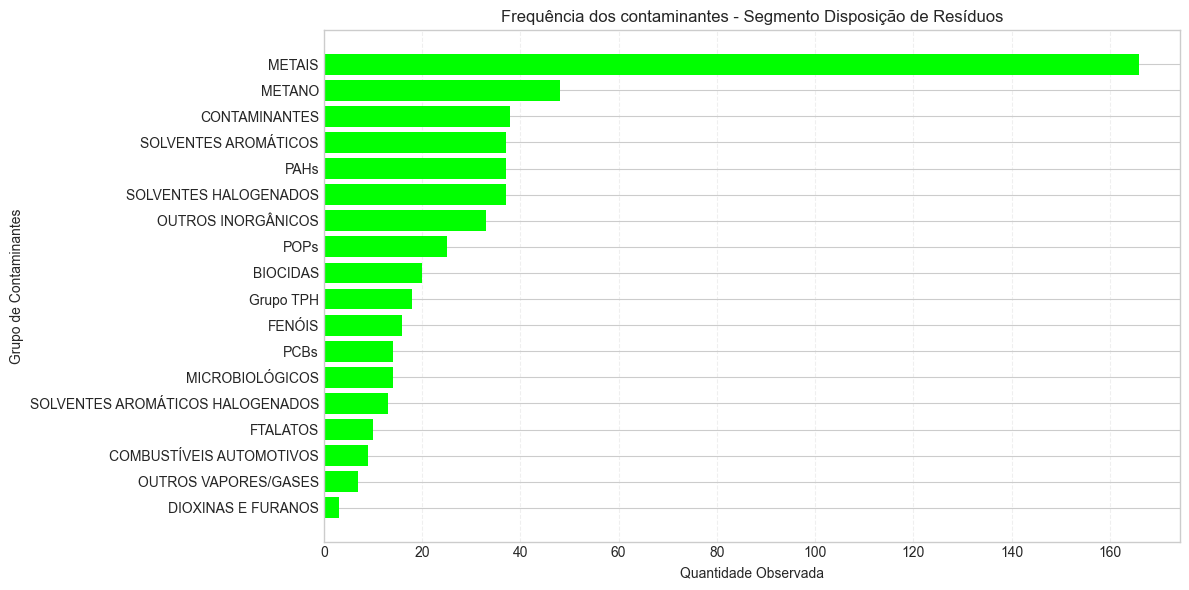

In [12]:
# Ordena os dados em ordem crescente para que as maiores barras apareçam no topo.
df_plot_residuos = df_contaminantes_residuos.sort_values(
    "Quantidade Observada",
    ascending=True
)

plt.figure(figsize=(12, 6))
plt.barh(
    df_plot_residuos["Grupo de Contaminantes"],
    df_plot_residuos["Quantidade Observada"],
    color=COR_RESIDUOS
)

plt.title("Frequência dos contaminantes - Segmento Disposição de Resíduos")
plt.xlabel("Quantidade Observada")
plt.ylabel("Grupo de Contaminantes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


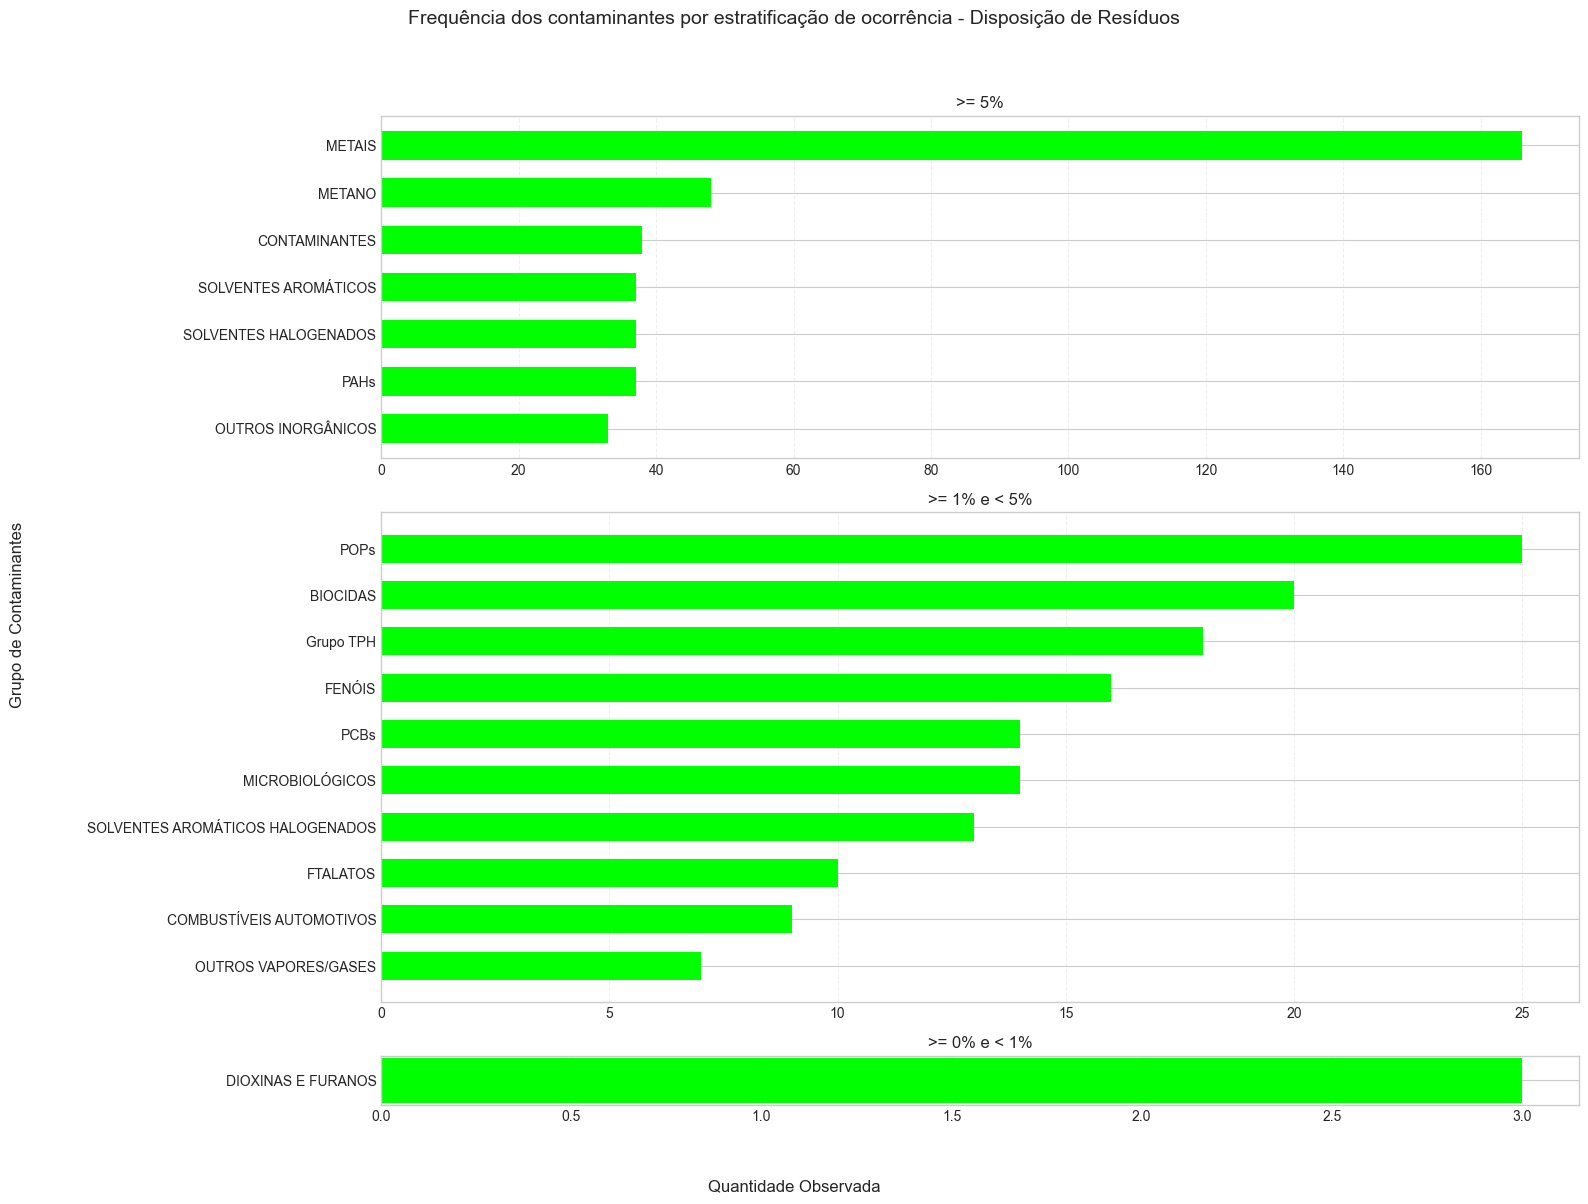

In [13]:
# Separa os contaminantes em três faixas percentuais e ordena cada grupo
# para manter a legibilidade do gráfico horizontal.
resid_conts_5pct = (
    df_contaminantes_residuos[df_contaminantes_residuos["% do total"] >= 5]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

resid_conts_1pct = (
    df_contaminantes_residuos[
        (df_contaminantes_residuos["% do total"] >= 1) &
        (df_contaminantes_residuos["% do total"] < 5)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

resid_conts_0pct = (
    df_contaminantes_residuos[
        (df_contaminantes_residuos["% do total"] >= 0) &
        (df_contaminantes_residuos["% do total"] < 1)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

# Organiza os grupos e os subtítulos da figura composta.
grupos_residuos = [
    (resid_conts_5pct, ">= 5%"),
    (resid_conts_1pct, ">= 1% e < 5%"),
    (resid_conts_0pct, ">= 0% e < 1%"),
]

# Define alturas proporcionais ao número de barras de cada estrato.
alturas = [max(1, len(df)) for df, _ in grupos_residuos]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, sum(alturas) * 0.7),
    gridspec_kw={"height_ratios": alturas}
)

for ax, (df_grupo, subtitulo) in zip(axes, grupos_residuos):
    # Mostra uma mensagem quando o estrato não tiver observações.
    if df_grupo.empty:
        ax.text(0.5, 0.5, f"Sem dados ({subtitulo})", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(
        df_grupo["Grupo de Contaminantes"],
        df_grupo["Quantidade Observada"],
        color=COR_RESIDUOS,
        height=0.6
    )
    ax.set_title(subtitulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

# Define os rótulos globais da figura composta.
fig.suptitle(
    "Frequência dos contaminantes por estratificação de ocorrência - Disposição de Resíduos",
    fontsize=14,
    y=0.98
)
fig.supxlabel("Quantidade Observada", fontsize=12, y=0.04)
fig.supylabel("Grupo de Contaminantes", fontsize=12, x=0.01)

plt.tight_layout(rect=[0.03, 0.06, 1, 0.95])
plt.show()


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Define constantes para padronizar a leitura e a visualização.
CAMINHO_ARQUIVO_COMERCIO = r"C:/Users/User/Documents/Códigos Github/Projeto Cetesb/contaminantes_comercio.xls"
COLUNA_CONTAMINANTES = "Grupo de Contaminantes"
COR_COMERCIO = "gold"

# Lê a planilha da atividade Comércio.
comercio = pd.read_excel(CAMINHO_ARQUIVO_COMERCIO, header=1)

# Exibe a estrutura da base original e as primeiras linhas.
comercio.info()
comercio.head()


<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Detalhes                         0 non-null      float64
 1   Ficha                            0 non-null      float64
 2   NIS da Área                      481 non-null    int64  
 3   Classificação Atual              481 non-null    str    
 4   Nome                             481 non-null    str    
 5   Endereço                         481 non-null    str    
 6   Município                        481 non-null    str    
 7   Coordenada                       481 non-null    str    
 8   UGRHI                            481 non-null    str    
 9   Grupo de Contaminantes           436 non-null    str    
 10  Medidas de Intervenção Adotadas  386 non-null    str    
dtypes: float64(2), int64(1), str(8)
memory usage: 41.5 KB


,Detalhes,Ficha,NIS da Área,Classificação Atual,Nome,Endereço,Município,Coordenada,UGRHI,Grupo de Contaminantes,Medidas de Intervenção Adotadas
0,NaN,NaN,7,Área Contaminada em Processo de Remediação (ACRe),VIAÇÃO RIBEIRÃO PIRES LTDA,"AVENIDA FRANCISCO MONTEIRO, 2065",Ribeirão Pires,"-23,7020671221132 \ -46,3975755656763",06 - ALTO TIETÊ,SOLVENTES AROMÁTICOS; PAHs,Medidas Emergenciais: Monitoramento Ambiental ...
1,NaN,NaN,16,Área Reabilitada para o Uso Declarado (AR),CIA DE DESENV. HAB. E URBANO DO EST. DE SP (CDHU),"R. JACUÍ, 55",Diadema,"-23,67064204 \ -46,61685682",06 - ALTO TIETÊ,METAIS; SOLVENTES AROMÁTICOS,Medidas de Controle Intitucional: Restrição ao...
2,NaN,NaN,18,Área em Processo de Monitoramento para Encerra...,TRANSPORTADORA CONTATTO LTDA.,"RODOVIA ANHANGUERA,",Limeira,"-22,55937865 \ -47,36758176",05 - PIRACICABA/CAPIVARI/JUNDIAÍ,PAHs,Medidas de Controle Intitucional: Restrição ao...
3,NaN,NaN,23,Área Contaminada em Processo de Reutilização (...,VILA EMA V DIALOGO EMPREENDIMENTOS IMOBILIARIO...,AVENIDA EMA 1370,São Paulo,7391317 \ 340516,07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,PAHs; Grupo TPH,Medidas Emergenciais: Remoção de Materiais (Pr...
4,NaN,NaN,56,Área Reabilitada para o Uso Declarado (AR),HESA 197 - INVESTIMENTOS IMOBILIARIOS LTDA.,AVENIDA DOM JAIME DE BARROS CAMARA 300,São Bernardo do Campo,"-23,70659 \ -46,56586",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,SOLVENTES HALOGENADOS; Grupo TPH; METANO; SOLV...,Medidas de Remediação: Extração de Vapores do ...


In [15]:
# Separa os contaminantes individuais, removendo nulos, espaços extras e valores vazios.
valores_unicos = (
    comercio[COLUNA_CONTAMINANTES]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
    .loc[lambda s: s.ne("")]
)

# Gera a tabela-resumo com a frequência absoluta de cada contaminante.
df_contaminantes_comercio = (
    valores_unicos
    .value_counts()
    .rename_axis("Grupo de Contaminantes")
    .reset_index(name="Quantidade Observada")
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_comercio


,Grupo de Contaminantes,Quantidade Observada
0,SOLVENTES AROMÁTICOS,191
1,PAHs,181
2,METAIS,181
3,Grupo TPH,144
4,COMBUSTÍVEIS AUTOMOTIVOS,121
5,SOLVENTES HALOGENADOS,66
6,METANO,30
7,CONTAMINANTES,27
8,PCBs,23
9,OUTROS INORGÂNICOS,20


In [16]:
# Valida a tabela consolidada e confere o total de ocorrências contabilizadas.
df_contaminantes_comercio.info()
print(f"Total de ocorrências contabilizadas: {df_contaminantes_comercio['Quantidade Observada'].sum()}")

df_contaminantes_comercio.head()


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Grupo de Contaminantes  19 non-null     str  
 1   Quantidade Observada    19 non-null     int64
dtypes: int64(1), str(1)
memory usage: 436.0 bytes
Total de ocorrências contabilizadas: 1025


,Grupo de Contaminantes,Quantidade Observada
0,SOLVENTES AROMÁTICOS,191
1,PAHs,181
2,METAIS,181
3,Grupo TPH,144
4,COMBUSTÍVEIS AUTOMOTIVOS,121


In [17]:
# Calcula a participação percentual de cada contaminante no total da atividade.
df_contaminantes_comercio = df_contaminantes_comercio.copy()

df_contaminantes_comercio["% do total"] = (
    df_contaminantes_comercio["Quantidade Observada"]
    .div(df_contaminantes_comercio["Quantidade Observada"].sum())
    .mul(100)
    .round(2)
)

# Reordena a tabela para manter o padrão visual da análise.
df_contaminantes_comercio = (
    df_contaminantes_comercio
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_comercio


,Grupo de Contaminantes,Quantidade Observada,% do total
0,SOLVENTES AROMÁTICOS,191,18.63
1,PAHs,181,17.66
2,METAIS,181,17.66
3,Grupo TPH,144,14.05
4,COMBUSTÍVEIS AUTOMOTIVOS,121,11.80
5,SOLVENTES HALOGENADOS,66,6.44
6,METANO,30,2.93
7,CONTAMINANTES,27,2.63
8,PCBs,23,2.24
9,OUTROS INORGÂNICOS,20,1.95


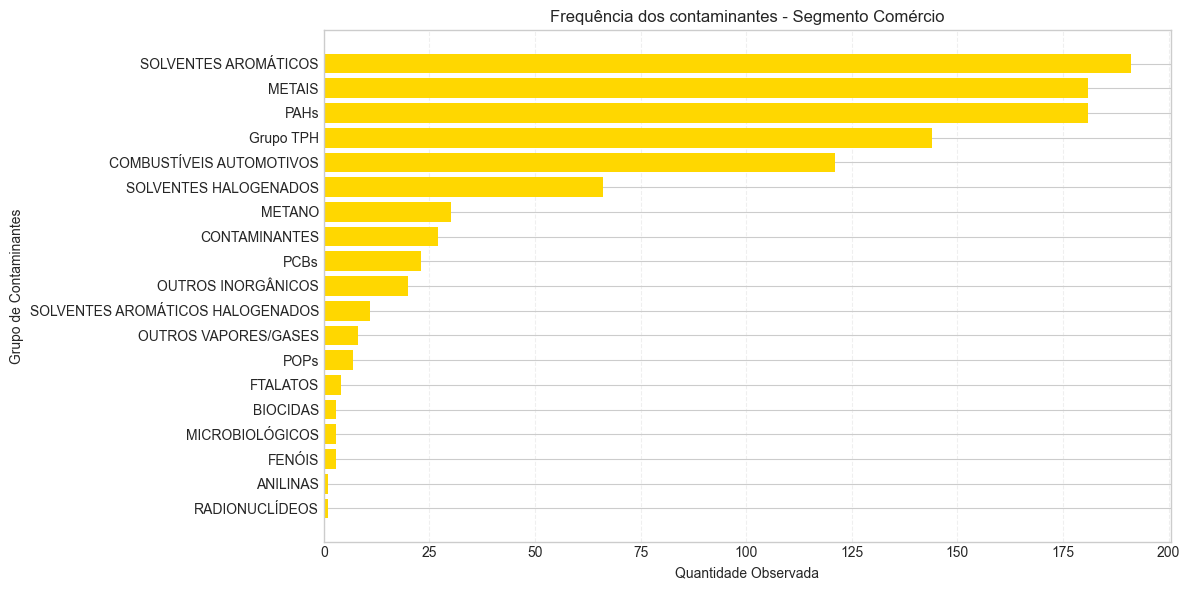

In [18]:
# Ordena os dados em ordem crescente para que as maiores barras apareçam no topo.
df_plot_comercio = df_contaminantes_comercio.sort_values(
    "Quantidade Observada",
    ascending=True
)

plt.figure(figsize=(12, 6))
plt.barh(
    df_plot_comercio["Grupo de Contaminantes"],
    df_plot_comercio["Quantidade Observada"],
    color=COR_COMERCIO
)

plt.title("Frequência dos contaminantes - Segmento Comércio")
plt.xlabel("Quantidade Observada")
plt.ylabel("Grupo de Contaminantes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


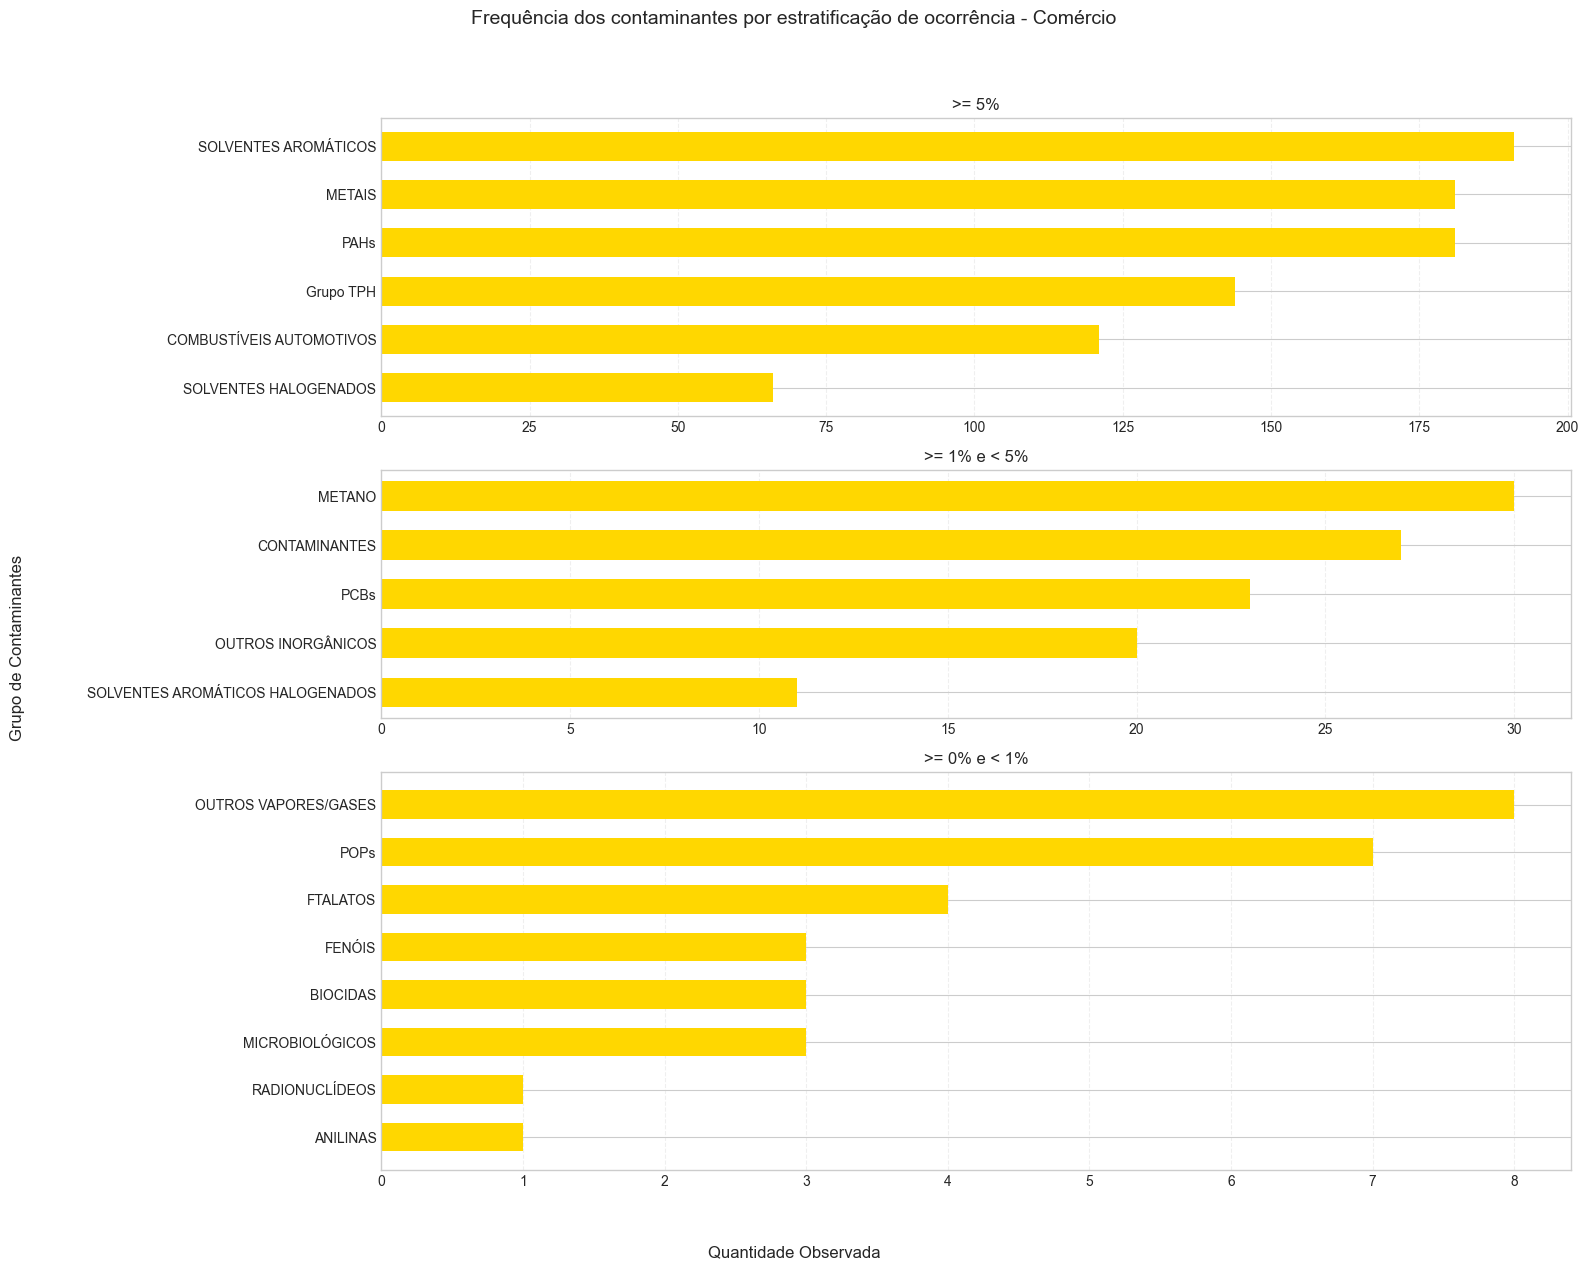

In [19]:
# Separa os contaminantes em três faixas percentuais e ordena cada grupo
# para manter a legibilidade do gráfico horizontal.
comerc_conts_5pct = (
    df_contaminantes_comercio[df_contaminantes_comercio["% do total"] >= 5]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

comerc_conts_1pct = (
    df_contaminantes_comercio[
        (df_contaminantes_comercio["% do total"] >= 1) &
        (df_contaminantes_comercio["% do total"] < 5)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

comerc_conts_0pct = (
    df_contaminantes_comercio[
        (df_contaminantes_comercio["% do total"] >= 0) &
        (df_contaminantes_comercio["% do total"] < 1)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

# Organiza os grupos e os subtítulos da figura composta.
grupos_comercio = [
    (comerc_conts_5pct, ">= 5%"),
    (comerc_conts_1pct, ">= 1% e < 5%"),
    (comerc_conts_0pct, ">= 0% e < 1%"),
]

# Define alturas proporcionais ao número de barras de cada estrato.
alturas = [max(1, len(df)) for df, _ in grupos_comercio]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, sum(alturas) * 0.7),
    gridspec_kw={"height_ratios": alturas}
)

for ax, (df_grupo, subtitulo) in zip(axes, grupos_comercio):
    # Mostra uma mensagem quando o estrato não tiver observações.
    if df_grupo.empty:
        ax.text(0.5, 0.5, f"Sem dados ({subtitulo})", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(
        df_grupo["Grupo de Contaminantes"],
        df_grupo["Quantidade Observada"],
        color=COR_COMERCIO,
        height=0.6
    )
    ax.set_title(subtitulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

# Define os rótulos globais da figura composta.
fig.suptitle(
    "Frequência dos contaminantes por estratificação de ocorrência - Comércio",
    fontsize=14,
    y=0.98
)
fig.supxlabel("Quantidade Observada", fontsize=12, y=0.04)
fig.supylabel("Grupo de Contaminantes", fontsize=12, x=0.01)

plt.tight_layout(rect=[0.03, 0.06, 1, 0.95])
plt.show()


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define constantes para padronizar a leitura, o tratamento e a visualização.
CAMINHO_ARQUIVO_POSTO = r"C:/Users/User/Documents/Códigos Github/Projeto Cetesb/contaminantes_posto_combustivel.xls"
COLUNA_CONTAMINANTES = "Grupo de Contaminantes"
COR_POSTO = "orangered"

# Lê a planilha da atividade Postos de Combustíveis.
posto_combustivel = pd.read_excel(CAMINHO_ARQUIVO_POSTO, header=1)

# Exibe a estrutura da base original e as primeiras linhas.
posto_combustivel.info()
posto_combustivel.head()


<class 'pandas.DataFrame'>
RangeIndex: 4683 entries, 0 to 4682
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Detalhes                         0 non-null      float64
 1   Ficha                            0 non-null      float64
 2   NIS da Área                      4683 non-null   int64  
 3   Classificação Atual              4683 non-null   str    
 4   Nome                             4683 non-null   str    
 5   Endereço                         4683 non-null   str    
 6   Município                        4683 non-null   str    
 7   Coordenada                       4683 non-null   str    
 8   UGRHI                            4683 non-null   str    
 9   Grupo de Contaminantes           4627 non-null   str    
 10  Medidas de Intervenção Adotadas  4497 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 402.6 KB


,Detalhes,Ficha,NIS da Área,Classificação Atual,Nome,Endereço,Município,Coordenada,UGRHI,Grupo de Contaminantes,Medidas de Intervenção Adotadas
0,NaN,NaN,1,Área Contaminada em Processo de Remediação (ACRe),AUTO POSTO PIRITUBANO LTDA,"AVENIDA RAIMUNDO PEREIRA DE MAGALHAES, 4520",São Paulo,"-23,489583635183 \ -46,7294751832022",07 - BAIXADA SANTISTA; 06 - ALTO TIETÊ,COMBUSTÍVEIS AUTOMOTIVOS; SOLVENTES AROMÁTICOS...,Medidas Emergenciais: Monitoramento Ambiental ...
1,NaN,NaN,4,Área Contaminada sob Investigação (ACI),DALLAS AUTO POSTO DE MARÍLIA LTDA,"AVENIDA VICENTE FERREIRA, 543",Marília,"-22,21523356 \ -49,93963815",20 - AGUAPEÍ; 21 - PEIXE; 17 - MÉDIO PARANAPANEMA,COMBUSTÍVEIS AUTOMOTIVOS; SOLVENTES AROMÁTICOS,Medidas de Controle Intitucional: Restrição ao...
2,NaN,NaN,5,Área Contaminada com Risco Confirmado (ACRi),MOLINA & DANTAS COMBUSTÍVEIS LTDA,"AVENIDA SANTOS DUMONT, 64",Monte Aprazível,"-20,76812741 \ -49,71011218",15 - TURVO/GRANDE; 19 - BAIXO TIETÊ; 18 - SÃO ...,COMBUSTÍVEIS AUTOMOTIVOS; SOLVENTES AROMÁTICOS,Medidas de Controle Intitucional: Restrição ao...
3,NaN,NaN,6,Área Contaminada sob Investigação (ACI),AUTO POSTO SHOPPING DE PEDREIRA LTDA. - EPP,"R. LUIS NOVO, 19",Pedreira,"-22,73975651 \ -46,8937846",05 - PIRACICABA/CAPIVARI/JUNDIAÍ,COMBUSTÍVEIS AUTOMOTIVOS; SOLVENTES AROMÁTICOS...,Medidas de Controle Intitucional: Restrição ao...
4,NaN,NaN,8,Área Reabilitada para o Uso Declarado (AR),AUTO POSTO MONTE ALEGRE LTDA,"RUA AMAZONAS, 800",São Caetano do Sul,"-23,61768907 \ -46,57021278",06 - ALTO TIETÊ,COMBUSTÍVEIS AUTOMOTIVOS; SOLVENTES AROMÁTICOS...,Medidas Emergenciais: Monitoramento Ambiental ...


In [21]:
# Separa os contaminantes individuais, removendo nulos, espaços extras e valores vazios.
valores_unicos = (
    posto_combustivel[COLUNA_CONTAMINANTES]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
    .loc[lambda s: s.ne("")]
)

# Gera a tabela-resumo com a frequência absoluta de cada contaminante.
df_contaminantes_posto_combustivel = (
    valores_unicos
    .value_counts()
    .rename_axis("Grupo de Contaminantes")
    .reset_index(name="Quantidade Observada")
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_posto_combustivel


,Grupo de Contaminantes,Quantidade Observada
0,COMBUSTÍVEIS AUTOMOTIVOS,4496
1,SOLVENTES AROMÁTICOS,3838
2,PAHs,2372
3,Grupo TPH,502
4,METAIS,42
5,SOLVENTES AROMÁTICOS HALOGENADOS,36
6,CONTAMINANTES,35
7,SOLVENTES HALOGENADOS,19
8,OUTROS VAPORES/GASES,16
9,METANO,9


In [22]:
# Valida a tabela consolidada e confere o total de ocorrências contabilizadas.
df_contaminantes_posto_combustivel.info()
print(
    f"Total de ocorrências contabilizadas: "
    f"{df_contaminantes_posto_combustivel['Quantidade Observada'].sum()}"
)

df_contaminantes_posto_combustivel.head()


<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Grupo de Contaminantes  17 non-null     str  
 1   Quantidade Observada    17 non-null     int64
dtypes: int64(1), str(1)
memory usage: 404.0 bytes
Total de ocorrências contabilizadas: 11383


,Grupo de Contaminantes,Quantidade Observada
0,COMBUSTÍVEIS AUTOMOTIVOS,4496
1,SOLVENTES AROMÁTICOS,3838
2,PAHs,2372
3,Grupo TPH,502
4,METAIS,42


In [23]:
# Calcula a participação percentual de cada contaminante no total da atividade.
df_contaminantes_posto_combustivel = df_contaminantes_posto_combustivel.copy()

df_contaminantes_posto_combustivel["% do total"] = (
    df_contaminantes_posto_combustivel["Quantidade Observada"]
    .div(df_contaminantes_posto_combustivel["Quantidade Observada"].sum())
    .mul(100)
    .round(2)
)

# Reordena a tabela para manter consistência visual e analítica.
df_contaminantes_posto_combustivel = (
    df_contaminantes_posto_combustivel
    .sort_values("Quantidade Observada", ascending=False, ignore_index=True)
)

df_contaminantes_posto_combustivel


,Grupo de Contaminantes,Quantidade Observada,% do total
0,COMBUSTÍVEIS AUTOMOTIVOS,4496,39.50
1,SOLVENTES AROMÁTICOS,3838,33.72
2,PAHs,2372,20.84
3,Grupo TPH,502,4.41
4,METAIS,42,0.37
5,SOLVENTES AROMÁTICOS HALOGENADOS,36,0.32
6,CONTAMINANTES,35,0.31
7,SOLVENTES HALOGENADOS,19,0.17
8,OUTROS VAPORES/GASES,16,0.14
9,METANO,9,0.08


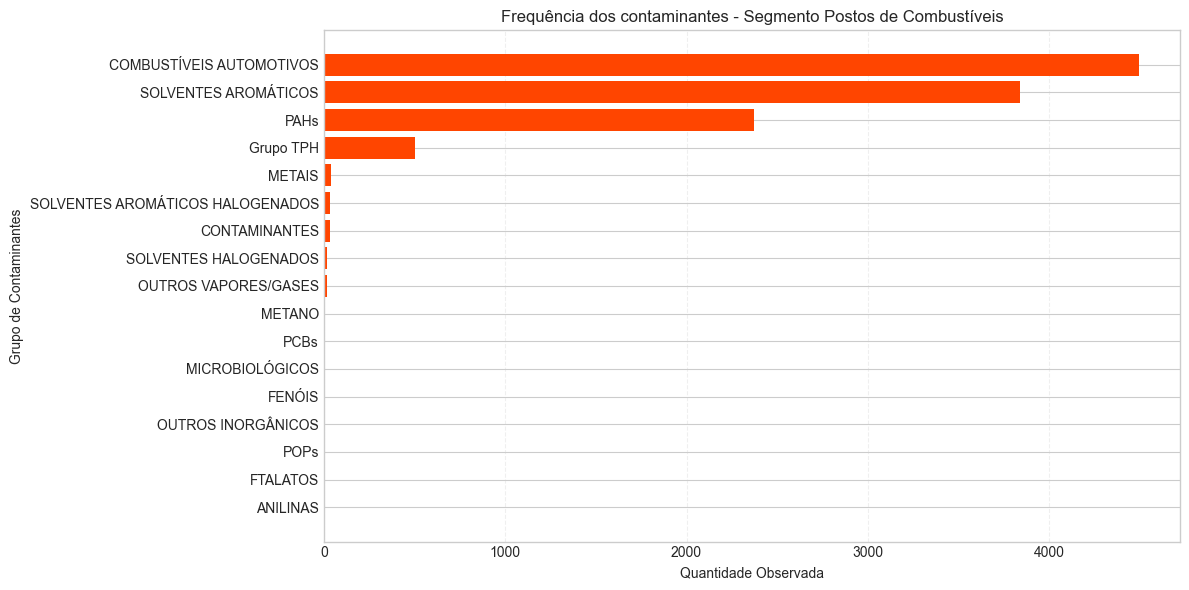

In [24]:
# Ordena os dados em ordem crescente para que as maiores barras apareçam no topo.
df_plot_posto = df_contaminantes_posto_combustivel.sort_values(
    "Quantidade Observada",
    ascending=True
)

plt.figure(figsize=(12, 6))
plt.barh(
    df_plot_posto["Grupo de Contaminantes"],
    df_plot_posto["Quantidade Observada"],
    color=COR_POSTO
)

plt.title("Frequência dos contaminantes - Segmento Postos de Combustíveis")
plt.xlabel("Quantidade Observada")
plt.ylabel("Grupo de Contaminantes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


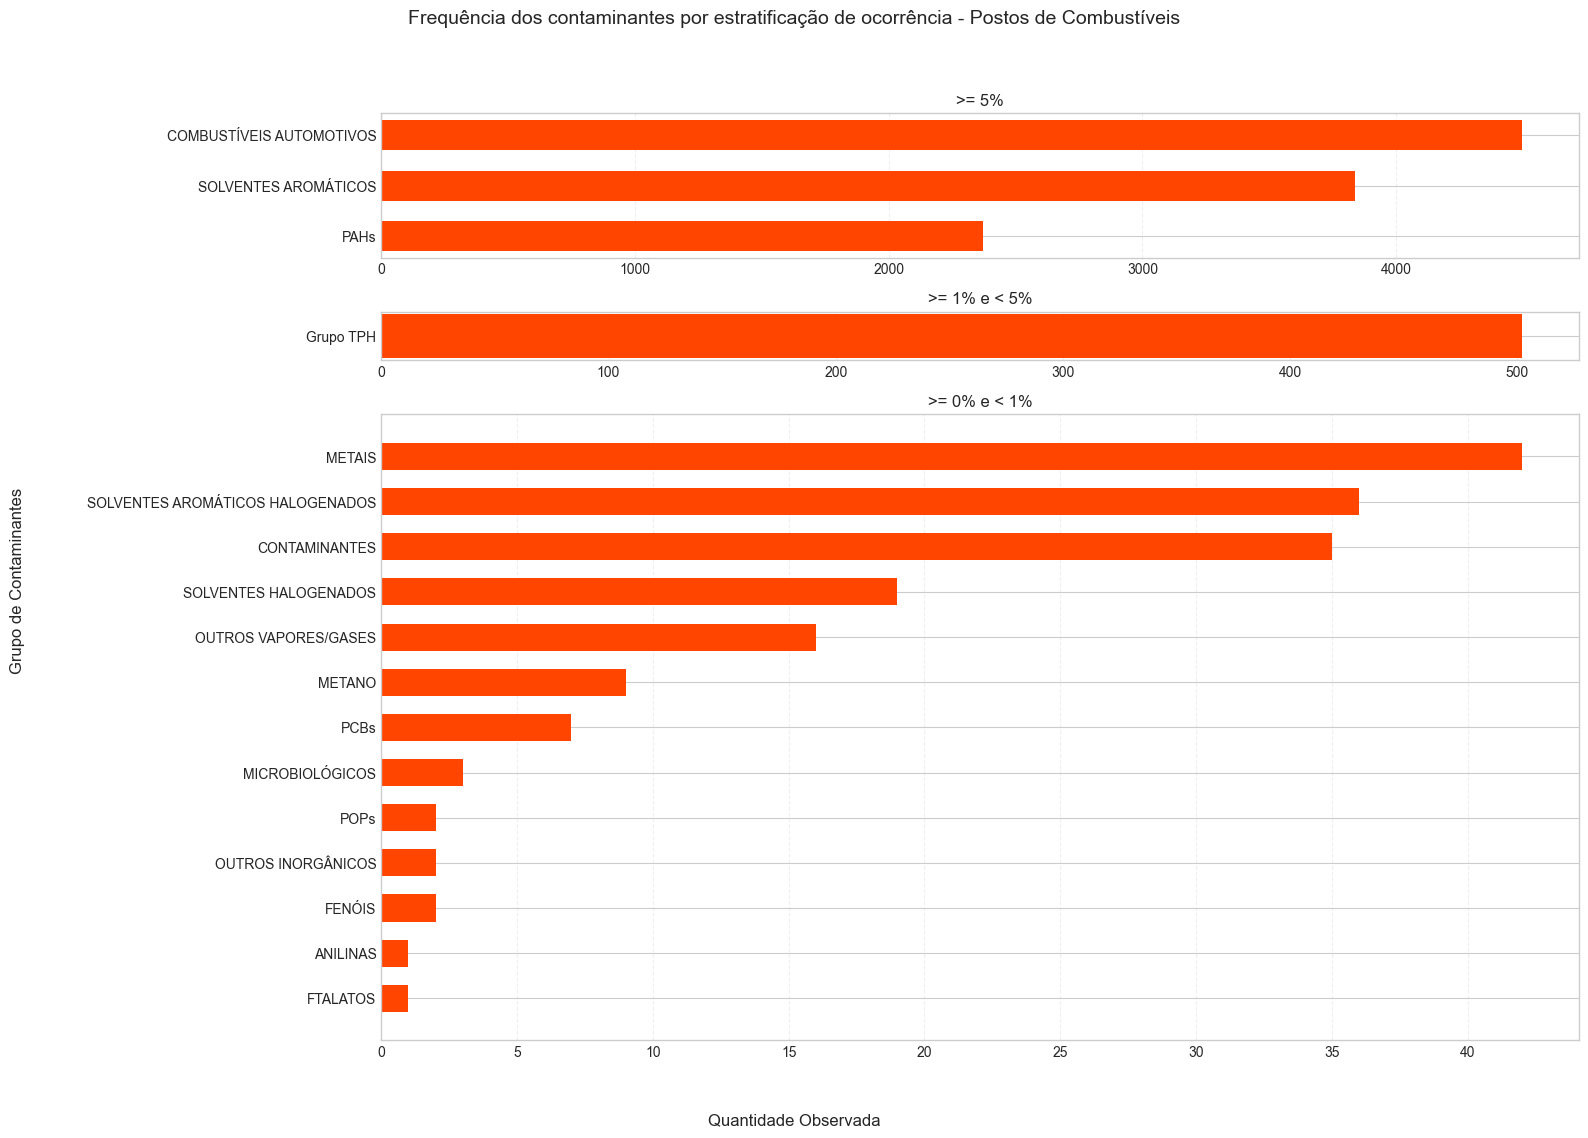

In [25]:
# Separa os contaminantes em três faixas percentuais e ordena cada grupo
# para manter a legibilidade do gráfico horizontal.
posto_conts_5pct = (
    df_contaminantes_posto_combustivel[
        df_contaminantes_posto_combustivel["% do total"] >= 5
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

posto_conts_1pct = (
    df_contaminantes_posto_combustivel[
        (df_contaminantes_posto_combustivel["% do total"] >= 1) &
        (df_contaminantes_posto_combustivel["% do total"] < 5)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

posto_conts_0pct = (
    df_contaminantes_posto_combustivel[
        (df_contaminantes_posto_combustivel["% do total"] >= 0) &
        (df_contaminantes_posto_combustivel["% do total"] < 1)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

# Organiza os grupos e os subtítulos da figura composta.
grupos_posto = [
    (posto_conts_5pct, ">= 5%"),
    (posto_conts_1pct, ">= 1% e < 5%"),
    (posto_conts_0pct, ">= 0% e < 1%"),
]

# Define alturas proporcionais ao número de barras de cada estrato.
alturas = [max(1, len(df)) for df, _ in grupos_posto]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, sum(alturas) * 0.7),
    gridspec_kw={"height_ratios": alturas}
)

for ax, (df_grupo, subtitulo) in zip(axes, grupos_posto):
    # Mostra uma mensagem quando o estrato não tiver observações.
    if df_grupo.empty:
        ax.text(0.5, 0.5, f"Sem dados ({subtitulo})", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(
        df_grupo["Grupo de Contaminantes"],
        df_grupo["Quantidade Observada"],
        color=COR_POSTO,
        height=0.6
    )
    ax.set_title(subtitulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

# Define os rótulos globais da figura composta.
fig.suptitle(
    "Frequência dos contaminantes por estratificação de ocorrência - Postos de Combustíveis",
    fontsize=14,
    y=0.98
)
fig.supxlabel("Quantidade Observada", fontsize=12, y=0.04)
fig.supylabel("Grupo de Contaminantes", fontsize=12, x=0.01)

plt.tight_layout(rect=[0.03, 0.06, 1, 0.95])
plt.show()


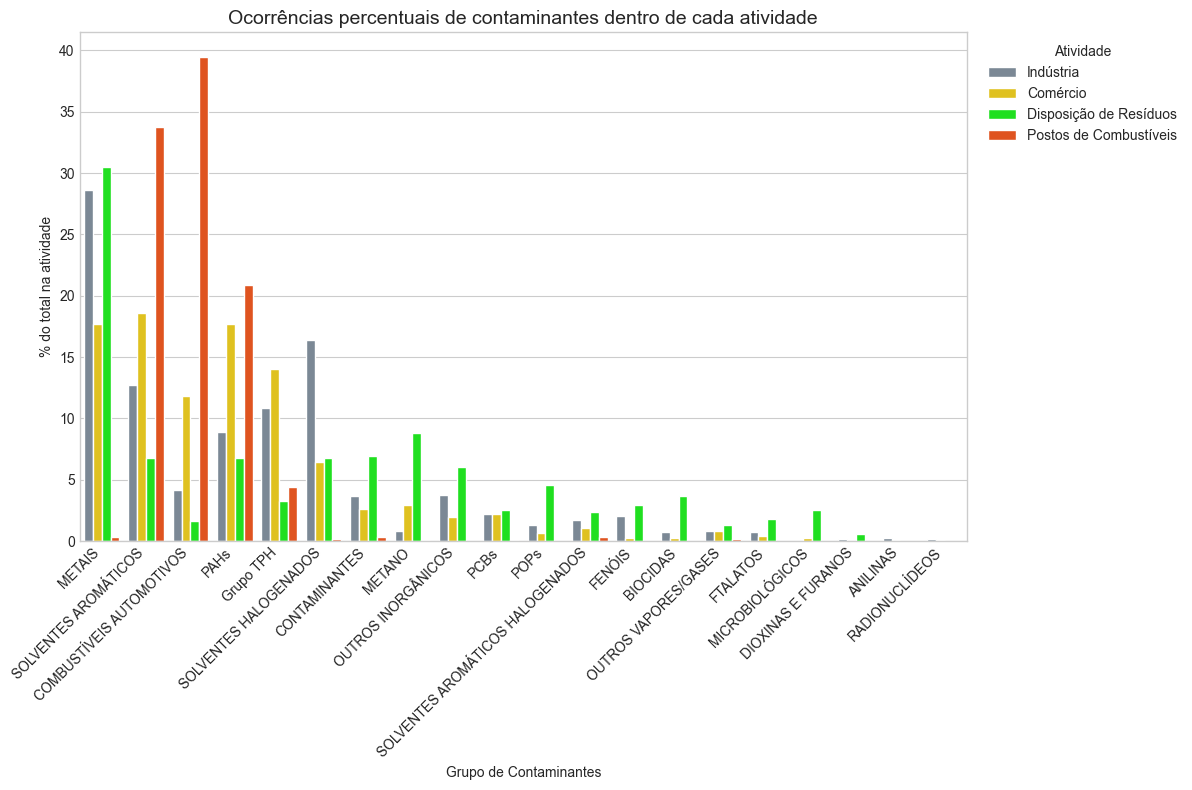

In [26]:
# Copia os DataFrames consolidados e adiciona a identificação da atividade.
df_ind = df_contaminantes_industria.copy()
df_ind["Atividade"] = "Indústria"

df_com = df_contaminantes_comercio.copy()
df_com["Atividade"] = "Comércio"

df_res = df_contaminantes_residuos.copy()
df_res["Atividade"] = "Disposição de Resíduos"

df_posto = df_contaminantes_posto_combustivel.copy()
df_posto["Atividade"] = "Postos de Combustíveis"

# Junta todas as atividades em um único DataFrame para comparação.
df_atividades = pd.concat([df_ind, df_com, df_res, df_posto], ignore_index=True)

# Mantém apenas as colunas necessárias para o gráfico percentual comparativo.
df_plot_percentual = df_atividades[
    ["Grupo de Contaminantes", "% do total", "Atividade"]
].copy()

# Ordena os contaminantes pela soma das porcentagens entre atividades.
ordem_contaminantes = (
    df_plot_percentual
    .groupby("Grupo de Contaminantes")["% do total"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# Define uma paleta fixa para manter a identidade visual de cada atividade.
paleta_atividades = {
    "Indústria": "lightslategrey",
    "Comércio": "gold",
    "Disposição de Resíduos": "lime",
    "Postos de Combustíveis": "orangered"
}

sns.set_style("whitegrid")

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_plot_percentual,
    x="Grupo de Contaminantes",
    y="% do total",
    hue="Atividade",
    order=ordem_contaminantes,
    palette=paleta_atividades
)

plt.title("Ocorrências percentuais de contaminantes dentro de cada atividade", fontsize=14)
plt.xlabel("Grupo de Contaminantes")
plt.ylabel("% do total na atividade")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Atividade", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


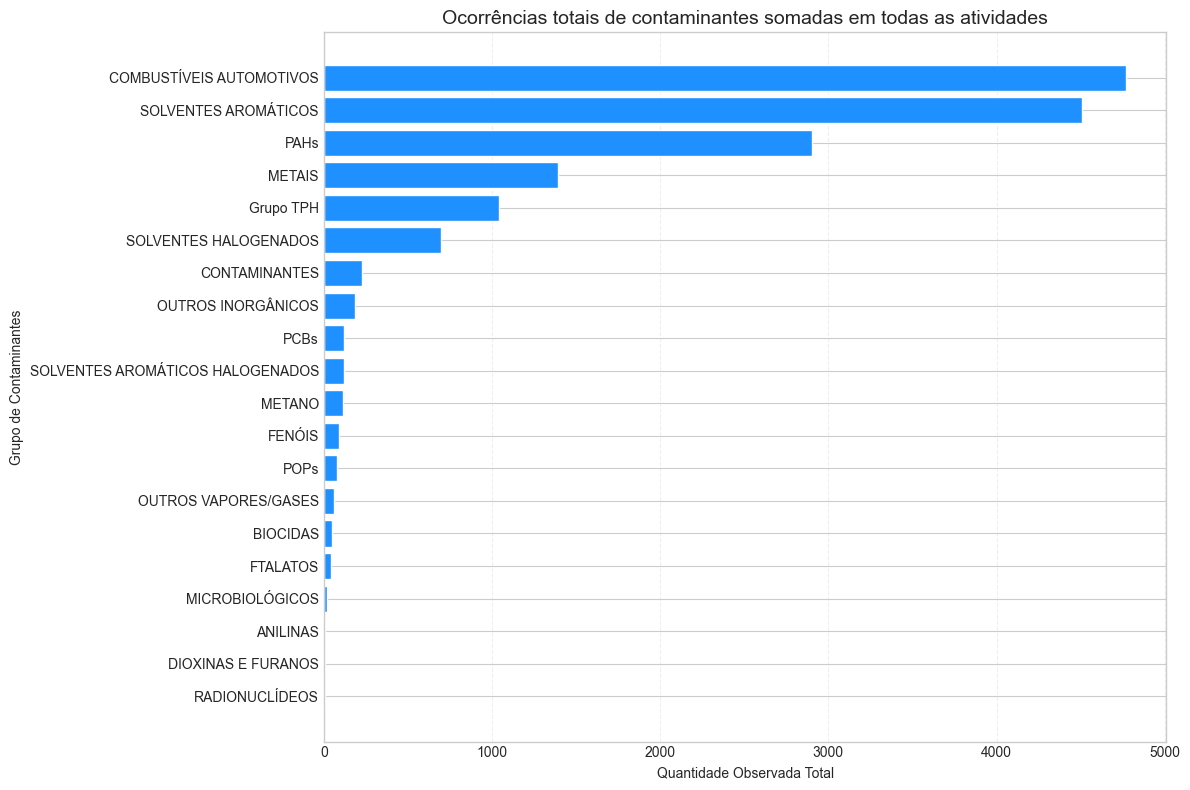

In [27]:
# Reaproveita a base conjunta das atividades para calcular o total agregado.
df_soma_total = (
    df_atividades
    .groupby("Grupo de Contaminantes", as_index=False)["Quantidade Observada"]
    .sum()
    .sort_values("Quantidade Observada", ascending=False)
)

# Cria um gráfico horizontal com a soma das ocorrências de todas as atividades.
plt.figure(figsize=(12, 8))
plt.barh(
    df_soma_total["Grupo de Contaminantes"],
    df_soma_total["Quantidade Observada"],
    color="dodgerblue"
)

plt.gca().invert_yaxis()
plt.title("Ocorrências totais de contaminantes somadas em todas as atividades", fontsize=14)
plt.xlabel("Quantidade Observada Total")
plt.ylabel("Grupo de Contaminantes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


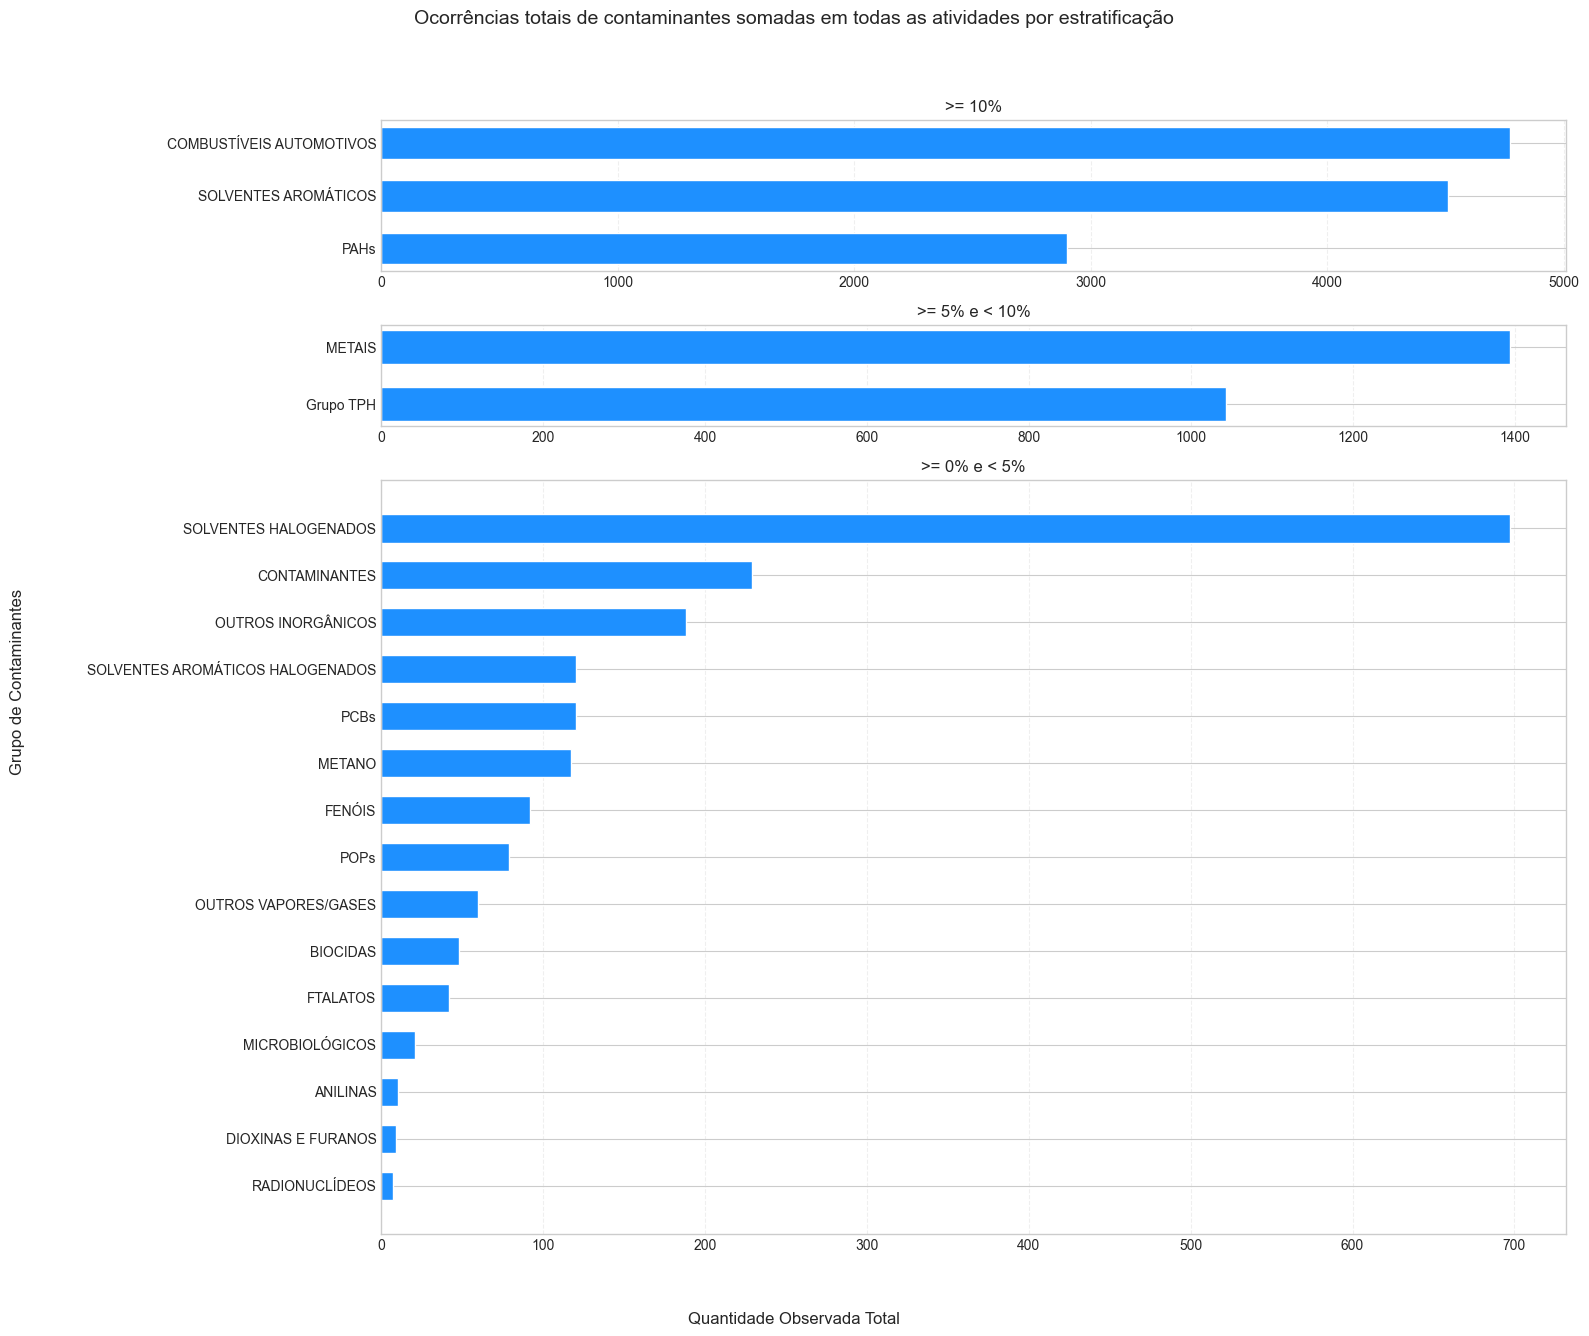

In [28]:
# Calcula a participação percentual de cada contaminante no total agregado.
df_soma_total = df_soma_total.reset_index(drop=True).copy()

df_soma_total["% do total"] = (
    df_soma_total["Quantidade Observada"]
    .div(df_soma_total["Quantidade Observada"].sum())
    .mul(100)
    .round(2)
)

# Estratifica os contaminantes em três faixas percentuais.
conts_10pct = (
    df_soma_total[df_soma_total["% do total"] >= 10]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

conts_5_10pct = (
    df_soma_total[
        (df_soma_total["% do total"] >= 5) &
        (df_soma_total["% do total"] < 10)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

conts_0_5pct = (
    df_soma_total[
        (df_soma_total["% do total"] >= 0) &
        (df_soma_total["% do total"] < 5)
    ]
    .sort_values("Quantidade Observada", ascending=True)
    .copy()
)

# Organiza os grupos da figura composta.
grupos_total = [
    (conts_10pct, ">= 10%"),
    (conts_5_10pct, ">= 5% e < 10%"),
    (conts_0_5pct, ">= 0% e < 5%")
]

# Define alturas proporcionais ao número de barras de cada estrato.
alturas = [max(1, len(df)) for df, _ in grupos_total]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, sum(alturas) * 0.7),
    gridspec_kw={"height_ratios": alturas}
)

for ax, (df_grupo, subtitulo) in zip(axes, grupos_total):
    # Mostra uma mensagem quando o estrato não tiver observações.
    if df_grupo.empty:
        ax.text(0.5, 0.5, f"Sem dados ({subtitulo})", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.barh(
        df_grupo["Grupo de Contaminantes"],
        df_grupo["Quantidade Observada"],
        color="dodgerblue",
        height=0.6
    )
    ax.set_title(subtitulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle(
    "Ocorrências totais de contaminantes somadas em todas as atividades por estratificação",
    fontsize=14,
    y=0.98
)
fig.supxlabel("Quantidade Observada Total", fontsize=12, y=0.04)
fig.supylabel("Grupo de Contaminantes", fontsize=12, x=0.01)

plt.tight_layout(rect=[0.03, 0.06, 1, 0.95])
plt.show()
